# Machine Learning Notes
Goal:

To learn about and run very simple versions of supervised ML models such as 
- OLS
- Logit
- KNN
- Support Vector Machine (SVM)
- Random Forest


The goal is to run a working model on a very simple example of predicting today's SPY prices using lagged returns. This exercise is to learn the basics of ML, not design an accurate trading signal model. 

## Bit of Background
3 types of machine learning tasks

Supervised - where the expected outcome is defined. Input values are mapped to output value so that any new input can be mapped to a new output. 
    Classification - finite set of defined outcomes (discrete) e.g., buy / sell
    Regression - infinite set of defined outcome (continuous) e.g., price of a stock
    
Unsupervised - where the expected outcome is not defined. The algorithm is given unlabelled datasets and figures out how to label / categorise them
    Dimensionality reduction - giving a reward for getting a right answer. This reduces the number of input variables in a dataset
    Clustering - finding similarities in the training data e.g., high vs low income countries
    
Reinforcement learning - retrofeeds the model with rewards and punishments

No fixed ratio of training to testing dataset size but training should always be greater than testing

# Learing to run a Linear Regression ML Model

<a id='library'></a> 

## Imports & Data

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html" target="_blank"> Scikit-Learn</a> library is used to perform the linear regression and has some of very common datasets to play with.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score


In [6]:
df = pd.read_csv('/Users/robmulligan/Downloads/SPY.csv', index_col=0)
# Convert index to datetime format
df.index = pd.to_datetime(df.index)

# Print the first five rows 
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-31,2498.939941,2509.239990,2482.820068,2506.850098,3442870000
2019-01-02,2476.959961,2519.489990,2467.469971,2510.030029,3733160000
2019-01-03,2491.919922,2493.139893,2443.959961,2447.889893,3822860000
2019-01-04,2474.330078,2538.070068,2474.330078,2531.939941,4213410000
2019-01-07,2535.610107,2566.159912,2524.560059,2549.689941,4104710000


The following code is going to run a regression getting the effect of the change in close price (labelled previous day returns) on todays close price. I.e., how much yesterday's close price predicts today's close price

In [9]:
# Creating a variable called "return" which is equal to the percentage change in the close price
df['return'] = df['Close'].pct_change()
# To get yesterday's returns, we take our new variable and shift it back one with .shift()
df['prev_day_returns'] = df['return'].shift()
#This drops any null values i.e., the first observation will be null because you cannot get the previous day return of day 0
df.dropna(inplace=True)

# Labelling X for our regression as previous day returns
X = df[['prev_day_returns']]

# keep time order, last 20% as test
# test_frac is the fraction for which we want to test i.e., we want 20% of the data for testing
test_frac = 0.20
#This is just calculating the split index i.e., it takes however many rows we have and splits it 80 / 20 (bc test frac is 20%)
#Int rounds the number to a whole number
#len(X) is the length of X
#Therefore the following equation says: "the data split is equal to the number of rows multipled by 0.8, rounded to the nearest number"
split = int(len(X) * (1 - test_frac))

# Split the independent data into training/testing sets
# The training set is everything up to the split i.e., :split i.e., the first 80%
X_train = X.iloc[:split]
# The testing set is everything after the split i.e., the last 20% of observations
X_test  = X.iloc[split:]
#iloc = interger location. It is a pandas method of selecting data by its position in the dataset
#dataframe.iloc[row_selection, column_selection]



In [10]:
df.head()

,Open,High,Low,Close,Volume,return,prev_day_returns
Date,,,,,,,
2019-01-09,2580.000000,2595.320068,2568.889893,2584.959961,4052480000,0.004098,0.009695
2019-01-10,2573.510010,2597.820068,2562.020020,2596.639893,3704500000,0.004518,0.004098
2019-01-11,2588.110107,2596.270020,2577.399902,2596.260010,3434490000,-0.000146,0.004518
2019-01-14,2580.310059,2589.320068,2570.409912,2582.610107,3664450000,-0.005258,-0.000146
2019-01-15,2585.100098,2613.080078,2585.100098,2610.300049,3572330000,0.010722,-0.005258


In [11]:
#We are looking at the effect of yesterday's returns on today's returns, therefore our Y variable is todays returns
# Dependent variable = 
df_y = df['return'] 

#The following code is doing the same as above, splitting the training and test data into a 80/20 split
y_train = df_y.iloc[:split]
y_test  = df_y.iloc[split:]
y_test.head()

Date
2020-04-13   -0.010105
2020-04-14    0.030573
2020-04-15   -0.022030
2020-04-16    0.005817
2020-04-17    0.026794
Name: return, dtype: float64


## The Actual Regression Model 
The `Linear_model` functions comes from the library scikit-learn


In [13]:
# naming the function so it is easier to call
regr = LinearRegression()

# Running the model on our training sets that were split earlier.
# The model learns from my training dataset how previous day returns match up with today's returns
# In OLS language it finds the line of best fit which minimises the error between the predicted and actual values
regr.fit(X_train, y_train)

LinearRegression()

In [16]:
#Showing what the ML model came up with
print(regr.coef_)  
print(regr.intercept_)  

[-0.3746142]
0.00056754313590093


In [17]:
# using what it has learned, we are now going to predict the returns from yesterday's returns and see how well the model performs
y_pred = regr.predict(X_test)

## Mean Squared Error

Mean square error (MSE) is the average of the square of the errors. The larger the number, the larger the error. 

In [18]:
#Calculating MSE
#Calling it MSE for convenience, mean_squared_error is from sklearn.metrics.
#It is going to get all the squared errors between what we predicted and the actual values from our dataset
mse  = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.6f}")
#Print mse with 6 decimals
#f string used to format the answer. How to use:
 #   mse - the variable containing your mean squared error value
 #   : - separates the variable from the formatting instructions
 #   .6 - show 6 digits after the decimal point
 #   f - format as a floating point number

Mean squared error: 0.000230


## Plot Regression Line
Plotting the regression line for the model to get a visual representation.

 R²:-0.0186


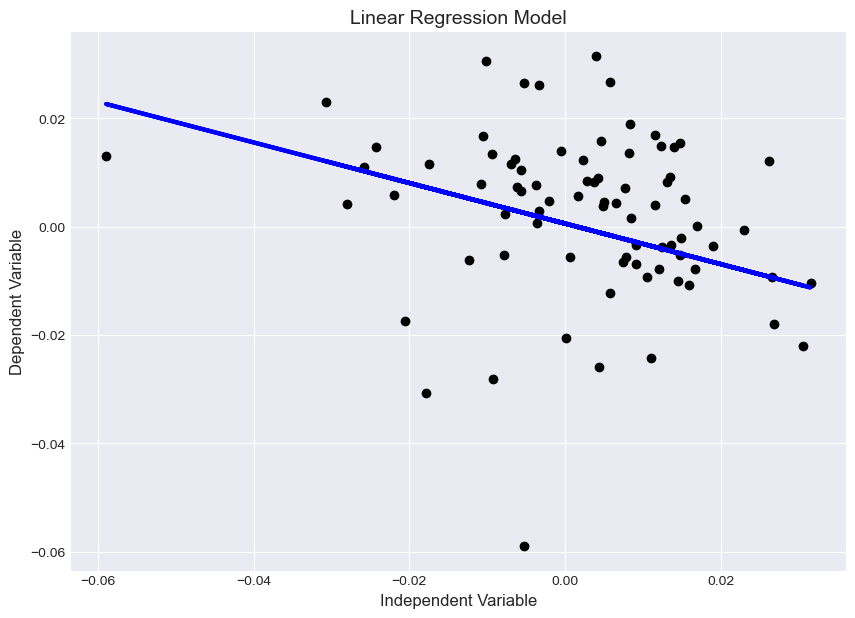

In [19]:
# although it will be extremely biased, calcualting the R^2 as a matter of form
r2   = r2_score(y_test, y_pred)                # same as regr.score(X_test, y_test)
print(f" R²:{r2:.4f}")

# Plot outputs
plt.figure(figsize=(10, 7)) # the size of the graph
plt.scatter(X_test, y_test, color='black') # put the x test on the bottom, y test on the vertical, scatter points black
plt.plot(X_test, regr.predict(X_test), color='blue', linewidth=3) #plotting our predictions against the actual values
plt.title('Linear Regression Model', fontsize=14)
plt.xlabel('Independent Variable', fontsize=12)
plt.ylabel('Dependent Variable', fontsize=12)
plt.show()

The above figure shows the regression line that the model has predicted and the actual data points used to predict. The model's R-square (same as regression score) is only 0.0534, which means the prediction is not too strong and the model under fits the points.

# Learning to Run a Logit ML Model

## Background on Logits
The logit model estimates the probability that y = 1 based on a number of predictors.
It computes a weighted sum of the input variables and then runs this through the logistic function (sigmoid function):

Given a constant c, x variables [X1,...,Xn] and corresponding weights w [W1,...,Wn], the logistic function is: 


$$ y = logistic (c \;+ \;w_{1} * \;x_{1} + \;w_{2} * \;x_{2}* \;w_{3} * \;x_{3} +... \;w_{n} * \;x_{n})$$
$$ y = 1/[1 + e^{-(c \;+ \;w_{1} * \;x_{1} + \;w_{2} * \;x_{2}* \;w_{3} * \;x_{3} +... \;w_{n} * \;x_{n})}]$$
$$ y = 1/[1 +e^{-x}]$$

Logits are used in machine learning for classification problems i.e., predict a binary outcome given a set of x variables

Shape of the sigmoid function:

![alternatvie text](https://upload.wikimedia.org/wikipedia/commons/8/88/Logistic-curve.svg)





## Imports & Data

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html" target="_blank"> Scikit-Learn</a> is used to perform the logistic regression. 

In [20]:
import numpy as np                 
import pandas as pd                    
import matplotlib.pyplot as plt                                       # Import matplotlib as an alias plt and set the style
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')  
from sklearn.linear_model import LogisticRegression                   # the classifier we'll fit
from sklearn.metrics import accuracy_score, confusion_matrix          # an evaluation method
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/robmulligan/Downloads/SPY.csv', index_col=0)
# Convert index to datetime format
df.index = pd.to_datetime(df.index)

# Print the first five rows 
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-31,2498.939941,2509.239990,2482.820068,2506.850098,3442870000
2019-01-02,2476.959961,2519.489990,2467.469971,2510.030029,3733160000
2019-01-03,2491.919922,2493.139893,2443.959961,2447.889893,3822860000
2019-01-04,2474.330078,2538.070068,2474.330078,2531.939941,4213410000
2019-01-07,2535.610107,2566.159912,2524.560059,2549.689941,4104710000


To illustrate how to use a logit model we are going to use 2 lags of returns to predict if today's return is positive or not. 
In Logit language, our target is whether Y = 1 i.e., today's return is positive
and our predictors / features and the last 2 days of returns. 

In [21]:
# Compute daily returns from 'Close'
df['return'] = df['Close'].pct_change()

# Use prior 2 day's return as the predictor. These are our X variables
df['1_day_lag_returns'] = df['return'].shift(1)
df['2_day_lag_returns'] = df['return'].shift(2)

# Binary target: Y = 1 if today's return > 0 else 0
df['target'] = (df['return'] > 0).astype(int)

# Drop the first row(s) created by pct_change/shift
df = df.dropna()

In [23]:
# Labelling our variables in an intuitive way
# BOTH lagged returns are used as features
features = ['1_day_lag_returns', '2_day_lag_returns']
X = df[features]        
y = df['target']       

# Splitting up our test and training datasets in an 80/20 fashion
test_frac = 0.20
split = int(len(df) * (1 - test_frac))

#This means that 80% of the first observations are training, the rest testing.
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# checking the shape of our data sets. There are 2 x variables so there should be 2 columns
# There is only 1 outcome variable so only 1 column. 
print("Shapes ->",
      "X_train:", X_train.shape, "y_train:", y_train.shape,
      "X_test:", X_test.shape,   "y_test:",  y_test.shape)

Shapes -> X_train: (318, 2) y_train: (318,) X_test: (80, 2) y_test: (80,)


## Logistic Regression Model

The `LogisticRegression` function is from the `sklearn.linear_model` library

**Syntax:**
```python
LogisticRegression(C=1e5) 

When running a logit ML model, you have to tell it how much you trust your training data. The higher the C value, the more you trust your data and the better the model will try to fit the training data. The high C value also makes the penalty for complexity very low.

A low C value is when you do not trust your training data. Any complexity is penalised heavily and the model is simplfied at the expense of fitting the data. 

The really high C value here is used just for show case purposes
    

In [24]:
# Create an instance of LogisticRegression and fit the data

logreg = LogisticRegression(C=1e5)  

# fit on training data
logreg.fit(X_train, y_train)

LogisticRegression(C=100000.0)

## Predicting & Evaluating the Model

We will use our trained logistic regression model to predict the next-day direction (up = 1, down/flat = 0) on the test window.

Report will cover:
- **Accuracy** (overall hit rate)
- **Confusion Matrix** (how many ups/downs we got right)q


In [1]:
# Class labels (0/1)
#Using the model we trained use the test set of X to predict if Y should be 1 or 0
y_pred = logreg.predict(X_test)


# Probabilities for the positive class (up day)
# Using the model we trained, use the test set of X to get the probabilities that Y = 1 (but only the probabilities that it was up, not down or flat)
y_proba = logreg.predict_proba(X_test)[:, 1]

# calculates an accuracy score based on the number of correct predictions. Puts the test and predictions side by side and puts the correct predictions over the total number of observations
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}") #formats the accuracy score nicely

NameError: name 'logreg' is not defined

In [26]:
cm  = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("Confusion matrix (rows=true, cols=pred):\n", cm)

Confusion matrix (rows=true, cols=pred):
 [[ 4 26]
 [ 4 46]]


            
               Down    Up
        Down  [ 4      26 ]
        Up    [ 4      46 ]

        - True negatives (DOWN DOWN) = 4 i.e., the return was down and the model predicted down
        - False negatives (UP DOWNN= 4 i.e., the return was up and the model predicted down
        - False positives (DOWN UP) = 26 i.e., the return was down but the model predicted up 
        - True positives (UP UP) = 46 i.e., the return was up and the model predicted up

# K Nearest Neighbour (KNN)

KNN works by finding the k closest, labelled training examples (called neighbours) to a new unlabelled data point and classifies it to the set of closest neighbours.
The algorithm does not attempt to construct a general internal model like other ML models, but compares new problems with the instances seen in training

## Importing data and libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('/Users/robmulligan/Downloads/SPY.csv', index_col=0)
df.index = pd.to_datetime(df.index)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-31,2498.939941,2509.239990,2482.820068,2506.850098,3442870000
2019-01-02,2476.959961,2519.489990,2467.469971,2510.030029,3733160000
2019-01-03,2491.919922,2493.139893,2443.959961,2447.889893,3822860000
2019-01-04,2474.330078,2538.070068,2474.330078,2531.939941,4213410000
2019-01-07,2535.610107,2566.159912,2524.560059,2549.689941,4104710000


## Creating the Variables:
Like the logistic regression, lagged returns are the features and the target is 1 if today's return > 0, else 0

NB: Supervised MLs all need targets and features

In [23]:
df['return'] = df['Close'].pct_change()
df['1_day_lag_returns'] = df['return'].shift(1)
df['2_day_lag_returns'] = df['return'].shift(2)
df['target'] = (df['return'] > 0).astype(int)
df = df.dropna()

Defining X and Y:

In [27]:
features = ['1_day_lag_returns', '2_day_lag_returns']
X = df[features]
y = df['target']

test_frac = 0.20
split = int(len(df) * (1 - test_frac))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print('X_train:', X_train.shape, 'X_test:', X_test.shape)

X_train: (316, 2) X_test: (79, 2)


## The Actual KNN Model
using `KNeighborsClassifier` from `sklearn.neighbours`

In [28]:
knn = KNeighborsClassifier()  # default k=5
knn.fit(X_train, y_train)

KNeighborsClassifier()

## Predict & Evaluate
We predict on the test set, report test accuracy and use the confusion matrix.

In [31]:
y_pred = knn.predict(X_test) #creating the y prediction using the x test set
acc = accuracy_score(y_test, y_pred) # gets how many were predicted, how many were predicted correctly, and puts one over the other
cm = confusion_matrix(y_test, y_pred, labels =[0, 1])
print('Test Accuracy:', round(acc,4))
print('Confusion Matrix (rows =true, cols=pred:\n', cm)

Test Accuracy: 0.481
Confusion Matrix (rows =true, cols=pred:
 [[12 18]
 [23 26]]


        - True negatives (DOWN DOWN) = 12 i.e., the return was down and the model predicted down
        - False negatives (UP DOWNN = 23 i.e., the return was up and the model predicted down
        - False positives (DOWN UP) = 18 i.e., the return was down but the model predicted up 
        - True positives (UP UP) = 26 i.e., the return was up and the model predicted up

## Creating a Decision Region Plot
This map shows when the market was up (i.e., y = 1) and when the market was down (i.e., y = 0)

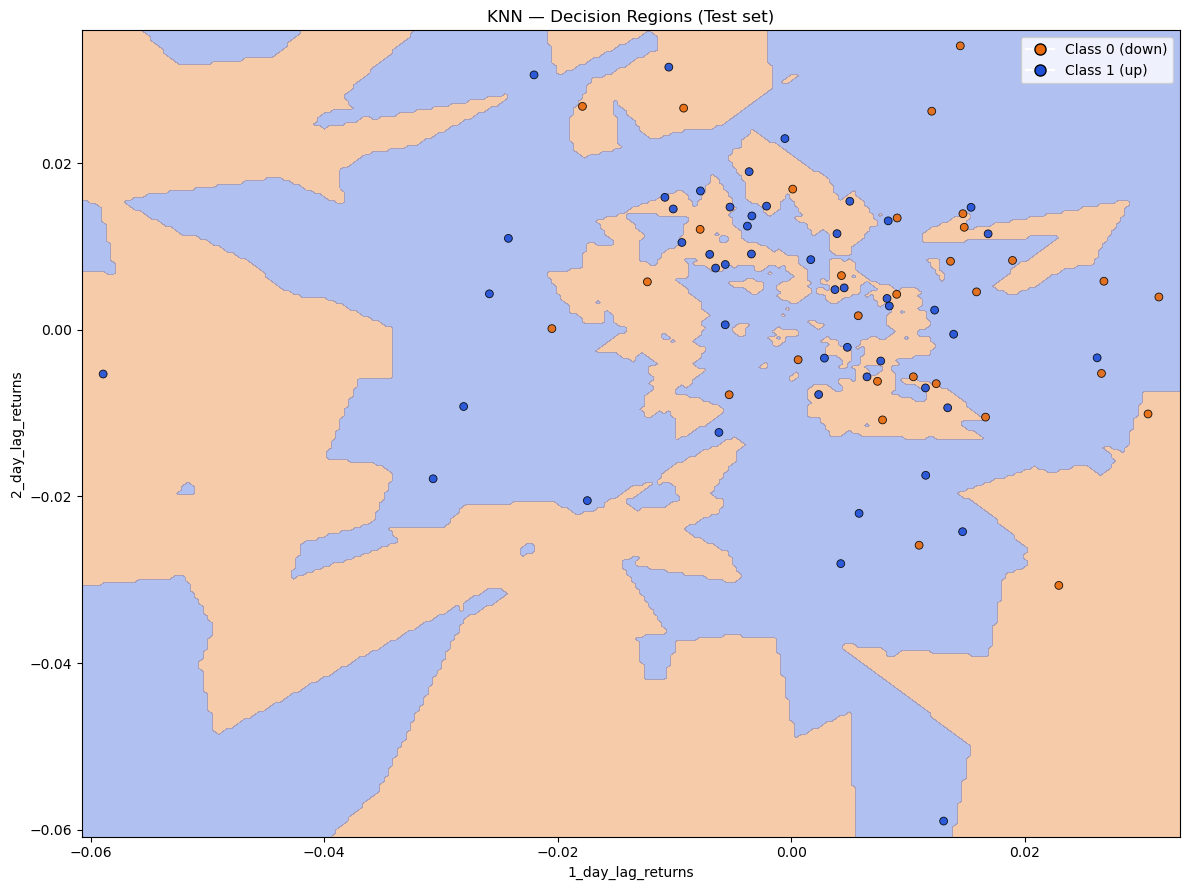

In [33]:
# Colour pallet
cmap_light = ListedColormap(['#FFE4C7', '#CFE8FF'])   # soft orange / soft blue (background)
cmap_bold  = ListedColormap(['#E86A0C', '#1E4FD7'])   # vibrant orange / deep blue (points)

# Getting the min and max of each dataframe, then adding padding so no data gets cut off
f1, f2 = features[0], features[1]
x1_lo, x1_hi = X_test[f1].min(), X_test[f1].max() 
x2_lo, x2_hi = X_test[f2].min(), X_test[f2].max()
pad1 = 0.02*(x1_hi - x1_lo) or 1e-6
pad2 = 0.02*(x2_hi - x2_lo) or 1e-6
x1_lo, x1_hi = x1_lo - pad1, x1_hi + pad1
x2_lo, x2_hi = x2_lo - pad2, x2_hi + pad2
# this is the data that will be plotted

#creating the grid and predictions
xx, yy = np.meshgrid( #This creates a grid of everything below it. 
    np.linspace(x1_lo, x1_hi, 250), #np.linespace(start, stop, n) between a start and stop value create n equally distance spots
    np.linspace(x2_lo, x2_hi, 250)  #in this case it is created 250 spots between the min and max values of our features
)
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
# the np.c_[xx.ravel(), yy.ravel()]) converts the 62,500 (250x250) rows in 2 columns,
# knn.predict predicts 0 / 1 for every point created
#.reshape(xx.shape) reshapes the predictions back to a 250 by 250 grid for the actual graph

#by creating xx and yy, we now have our X and Y axes for the graph to call later. xx is all the points of feature 1 and yy contains all the points of feature 2

# Plot
plt.figure(figsize=(12, 9))
# Background regions for classes {0,1}
plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=cmap_bold, alpha=0.35) #contourf colours in the background

# Test points colored by true class {0,1}
plt.scatter(
    X_test[f1], X_test[f2], #these are our x and y coordinates
    c=y_test.to_numpy(), #This means colour is equal to the value from the y_test data
    cmap=cmap_bold, # colour map to use is the colours defined earlier. first colour was orange, so down days (y=0) are orange. Second colour was blue so if y=1 the dot will be blue
    vmin=0, vmax=1, #this tells matplotlib that the smallest value is 0 and the biggest is 1. This ensures that down days get orange and up days get blue
    s=32, #size of the dot
    edgecolor='k', #the outline of each dot is black 
    linewidth=0.6, # the width of the outline is thin 
    alpha=0.9, #this is transparency, 0.9 means slighlty transparent so you can see overlap
    zorder=2 # this means that the dots appear on top of the background colours
)

# Creating a custom legend
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Class 0 (down)',
           markerfacecolor=cmap_bold(0), markeredgecolor='k', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Class 1 (up)',
           markerfacecolor=cmap_bold(1), markeredgecolor='k', markersize=8),
]
plt.legend(handles=legend_handles, loc='upper right', frameon=True)

plt.xlabel(f1)
plt.ylabel(f2)
plt.title('KNN — Decision Regions (Test set)')
plt.xlim(x1_lo, x1_hi)
plt.ylim(x2_lo, x2_hi)
plt.tight_layout()
plt.show()


## Interpreting the graph
- **Axes:** `1_day_lag_returns` (x) vs `2_day_lag_returns` (y).
- **Background colors:** Model’s predicted class in each area (0 = down, 1 = up).  
  The boundary between colors is where the model is undecided.
- **Dots:** Test-set days, colored by the **true** class.  
  A dot inside its own class region = correct; in the other region = error.
- **Confidence intuition:** Points farther from the boundary are typically more confident; near the line are uncertain.
- **Why the patchy regions?** KNN bases decisions on nearby points, so shapes can look “island-like” rather than a straight line.



# Overall Conclusion

Based on this rudimentary analysis, the logit model seemed to perform the best out of the three models and it had the greatest number of true positives (i.e., predicting the market was up and the market was actually up).
However, our C value was incredibly high which would not be the case when using this model for research.

# Support Vector Machine (SVM)

SVM finds a straight line that separates the classes while maximising the margin to the closest points (the support vectors). 
SVM assumes the classes can be separated linearly, and on this assumption, the SVM finds the separating line that leaves as much space as possible between the two classes. By doing this, the model is robust to noise, as the line does not change much with the introduction of new data. The support vectors are the closest points to the "hyperplane" (the name for the separating line in high demensions). Using the support vectors, the model can now classify new data to either side of the decision boundary (another name for the hyperplane/separating line). 

SVMs are used for classification problems.
SVMs can be used for non-linear problems, but they need to use "kernel functions" to transform the data higher-dimensional space to enable linear separation of the data.

## Importing the data and SVM 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('/Users/robmulligan/Downloads/SPY.csv', index_col=0)
df.index = pd.to_datetime(df.index)
df.head()


,Open,High,Low,Close,Volume
Date,,,,,
2018-12-31,2498.939941,2509.239990,2482.820068,2506.850098,3442870000
2019-01-02,2476.959961,2519.489990,2467.469971,2510.030029,3733160000
2019-01-03,2491.919922,2493.139893,2443.959961,2447.889893,3822860000
2019-01-04,2474.330078,2538.070068,2474.330078,2531.939941,4213410000
2019-01-07,2535.610107,2566.159912,2524.560059,2549.689941,4104710000


## Creating the dependent and independent variables
Lagged returns are the features and the binary target = 1 if today's return > 0, otherwise it is 0.
Also the last 20% are kept for testing

In [3]:
df['return'] = df['Close'].pct_change()
df['1_day_lag_returns'] = df['return'].shift(1)
df['2_day_lag_returns'] = df['return'].shift(2)
df['target'] = (df['return'] > 0).astype(int)
df = df.dropna()

features = ['1_day_lag_returns', '2_day_lag_returns']
X = df[features]
y = df['target']

# Time-aware split: last 20% as test
test_frac = 0.20
split = int(len(df) * (1 - test_frac))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print('X_train:', X_train.shape, 'X_test:', X_test.shape)

X_train: (318, 2) X_test: (80, 2)


## Running the SVM Model
Using the `SVC` from `sklearn.svm` library

**Syntax:**
```python
SVC(kernel='linear', C=1.0)
```

**Parameters used:**
- `kernel='linear'` (straight-line boundary)
- `C=1.0` (regularization; higher C = weaker regularization)

In [7]:
svc = SVC(kernel='linear', C=1.0)
svc.fit(X_train, y_train)
print('Model:', svc)
print('coef_:', svc.coef_)
print('intercept_:', svc.intercept_)

Model: SVC(kernel='linear')
coef_: [[-0.00373721  0.01866848]]
intercept_: [1.0001825]


## Predict & Evaluate
We predict on the test set, report test accuracy and the confusion matrix.

In [9]:
#to make a y prediction variable, name is then put the model_name.predict(data_you're_predicting_from)
y_pred = svc.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print('Test accuracy:', round(acc, 4))
print('Confusion Matrix (rows=true, cols=pred):\n', cm)

Test accuracy: 0.625
Confusion Matrix (rows=true, cols=pred):
 [[ 0 30]
 [ 0 50]]


- Down, Down 0 : meaning the market was down, and the model predicted down 0 times
- Down, Up 30: Meaning the market was down and the model predicted up 30 times
- Up, Down 0: Meaning the market was up and the model predicted down 0 times
- Up, Up 50: Meaning the market was up and the model predicted up 50 times

## Example of a SVM hyperplane graph using random data (*from course materials*)
**Purpose:** illustrate what a linear SVM learns — one separating line and two margin lines.

**Read it:**
- Solid line = **decision boundary** where the SVM score = 0.
- Dashed lines = **margins** at score = ±1.
- **Support vectors** lie on or inside the margins and determine the boundary.
- The margin width reflects the trade-off set by **C** (lower C → wider margin, higher C → tighter fit).

This is a geometry demo only. The toy plot builds intuition for what the SVM is doing.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


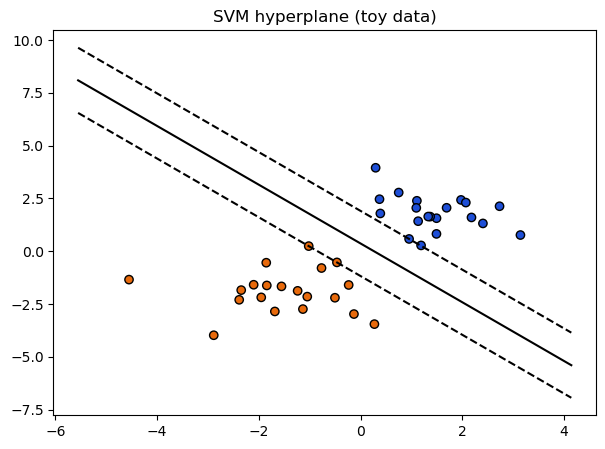

In [10]:
# Optional: toy demo to show hyperplane & margins

np.random.seed(0)
X_toy = np.r_[np.random.randn(20,2)-[2,2], np.random.randn(20,2)+[2,2]]
y_toy = np.r_[np.zeros(20), np.ones(20)]
svc_toy = SVC(kernel='linear', C=1.0).fit(X_toy, y_toy)
w = svc_toy.coef_.ravel(); b = float(svc_toy.intercept_)
xx = np.linspace(X_toy[:,0].min()-1, X_toy[:,0].max()+1, 200)
yy = -(w[0]/w[1])*xx - b/w[1]
yy_up = yy + 1.0/w[1]; yy_down = yy - 1.0/w[1]
plt.figure(figsize=(7,5))
plt.plot(xx, yy, 'k-'); plt.plot(xx, yy_up, 'k--'); plt.plot(xx, yy_down, 'k--')
plt.scatter(X_toy[:,0], X_toy[:,1], c=y_toy, cmap=ListedColormap(['#E86A0C','#1E4FD7']), edgecolor='k')
plt.title('SVM hyperplane (toy data)'); plt.show()


# Random Forest
Random Forest, is a method in machine learning capable of performing both regression and classification tasks.

Random Forest comprises of decision trees, which are graphs of decisions representing their course of action or statistical probability. These multiple trees are plotted to a single tree called the Classification and Regression (CART) Model. 
Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression which makes it an **ensemble** learning technique


For **classification problems**, data is run through each tree which then votes on its classification e.g., is this email spam or not.The forest then chooses the classification with the maximum number of votes. 


For **regression**, data is run through each tree which gives an output answer e.g., house price based on certain attributes. Instead of choosing a majority answer, the final decision will be an average of all the outputs

<b>The Technical Workings:</b>
1. It assumes the number of cases as N. Then, randomly but with replacement, the sample of these N cases is taken out, which will be the training set.
2. Considering M to be the input variables, a number m is selected such that m < M. The best split between m and M is used to split the node. The value of m is held constant as the trees are grown.
3. Each tree is grown as large as possible.
4. By aggregating the predictions of n trees (i.e., majority votes for classification, the average for
regression), random forest predicts the new data.


![alt text](https://d2a032ejo53cab.cloudfront.net/Glossary/UclBTDKs/image-3.png)

For example, the final class would be class N

Random Forest has certain advantages and disadvantages.

<b>Advantages</b>
1. This method balances the errors which are present in the dataset.
2. It is an effective method because it maintains accuracy even if it has to estimate the missing data.
3. Using the out-of-bag error estimate removes the need for a set-aside test set.
4. Random Forest helps in unsupervised clustering, data views, and outlier detection.
5. It reduces data management time and pre-processing tasks. 

<b>Disadvantages</b>

Disadvantages of the random forest may include its inability to be at par excellence for the regression problem as it does not give precise continuous nature predictions. It cannot predict beyond the range in the
training data. Further, it does not provide complete control to the modeller.

## Import libraries and data:

In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('/Users/robmulligan/Downloads/SPY.csv', index_col=0)
df.index = pd.to_datetime(df.index)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-31,2498.939941,2509.239990,2482.820068,2506.850098,3442870000
2019-01-02,2476.959961,2519.489990,2467.469971,2510.030029,3733160000
2019-01-03,2491.919922,2493.139893,2443.959961,2447.889893,3822860000
2019-01-04,2474.330078,2538.070068,2474.330078,2531.939941,4213410000
2019-01-07,2535.610107,2566.159912,2524.560059,2549.689941,4104710000


## The Exercise: 
Based on 4 features, use a random forest model to predict whether tomorrow's stock price will be greater than today's using data from the SPY500

## Creating the features (independent variables):
The features are:
1. Ratio of open and close price i.e., how much did the stock fall (>1) or grow (<1) during the day. The model will look for momentum or mean reversion patterns
2. Ratio of high and low price i.e., how much trading volatility was there. The model will learn about news events or macro shocks
3. 1-day lag returns i.e., yesterday's return. the model will again learn patterns such as mean reversion and momentum
4. 2-day lag returns i.e., the day before yesterday's return. 

In [3]:
# how to create features:
# df.[name of feature] = df[column of data from dataset].function i.e., how you want to change it
# follows basic maths principles + - / *

df['return'] = df['Close'].pct_change()
df['Open/Close'] = (df['Open']/df['Close'])
df['High/Low'] = (df['High']/ df['Low'])
df['1_day_lagged_returns'] = df['return'].shift(1)
df['2_day_lagged_returns'] = df['return'].shift(2)
df.dropna(inplace=True)
X = df[['Open/Close','High/Low', '1_day_lagged_returns','2_day_lagged_returns']]
X.head()


,Open/Close,High/Low,1_day_lagged_returns,2_day_lagged_returns
Date,,,,
2019-01-04,0.977247,1.025761,-0.024757,0.001268
2019-01-07,0.994478,1.016478,0.034336,-0.024757
2019-01-08,0.997553,1.012663,0.007010,0.034336
2019-01-09,0.998081,1.010289,0.009695,0.007010
2019-01-10,0.991092,1.013973,0.004098,0.009695


## Creating the dependent variable
Y will be a binary variable which = 1 when tomorrow's close price is greater than today's close price
else = -1

In [4]:
#Confusingly (-1) gives tomorrow's close price
y = np.where(df['Close'].shift(-1) > df['Close'], 1, -1)
y[:10]

array([ 1,  1,  1,  1, -1, -1,  1,  1,  1,  1])

In [6]:
split = int(len(df) * 0.75)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Running / Training the actual model:
The `RandomForestClassifier` function is from sklearn and is used to train and fit the model. The syntax of the following function is as follows:
```python
RandomForestClassifier()
```
Parameters: 

    1. random_state (Make it any constant value to produce same results)
    
    
Returns: 

    1. Predicting the test dataset

In [7]:
# Create and fit the model on train dataset
clf = RandomForestClassifier(random_state=5) #training
model = clf.fit(X_train, y_train) #fitting

## Accuracy Score
The model is trained on the training dataset. Now it's time to test the accuracy of the model on the test dataset. We will use `accuracy_score` function to test the accuracy

In [29]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Prediction Accuracy:', round(acc, 4)*100)

Prediction Accuracy: 59.79


This is a very simple model with an accuracy of around 59.79% on the test dataset.

## Decision Tree Plot

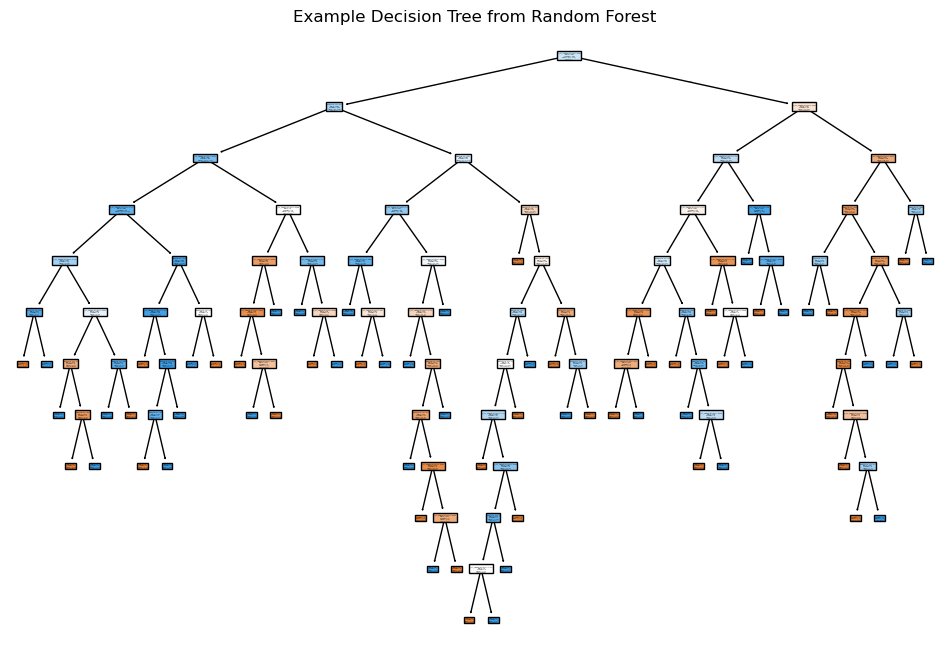

In [13]:
# extracting one tree from the forest to plot
tree = clf.estimators_[0]

plt.figure(figsize=(12,8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['Down','Up'],
    filled=True
)
plt.title("Example Decision Tree from Random Forest")
plt.show()